开始加载数据...
(132, 3) (132, 5)
数据标准化完成
数据已保存至 '学习数据集.xlsx'
开始训练MLP模型...
Epoch 20/300, Train Loss: 0.3369, Val Loss: 0.0926, Train RMSE: 0.5281, Val RMSE: 0.3043, Train MAE: 0.4247, Val MAE: 0.2306, Train MSE: 0.3369, Val MSE: 0.0926, LR: 0.001000
Epoch 40/300, Train Loss: 0.0602, Val Loss: 0.0440, Train RMSE: 0.2454, Val RMSE: 0.2098, Train MAE: 0.1991, Val MAE: 0.1540, Train MSE: 0.0602, Val MSE: 0.0440, LR: 0.001000
Epoch 60/300, Train Loss: 0.0963, Val Loss: 0.0442, Train RMSE: 0.3001, Val RMSE: 0.2104, Train MAE: 0.2365, Val MAE: 0.1575, Train MSE: 0.0963, Val MSE: 0.0442, LR: 0.001000
Epoch 80/300, Train Loss: 0.0577, Val Loss: 0.0362, Train RMSE: 0.2377, Val RMSE: 0.1902, Train MAE: 0.1871, Val MAE: 0.1300, Train MSE: 0.0577, Val MSE: 0.0362, LR: 0.001000
Epoch 100/300, Train Loss: 0.0505, Val Loss: 0.0259, Train RMSE: 0.2247, Val RMSE: 0.1609, Train MAE: 0.1762, Val MAE: 0.0978, Train MSE: 0.0505, Val MSE: 0.0259, LR: 0.000500
Epoch 120/300, Train Loss: 0.0414, Val Loss: 0.0457, Tr

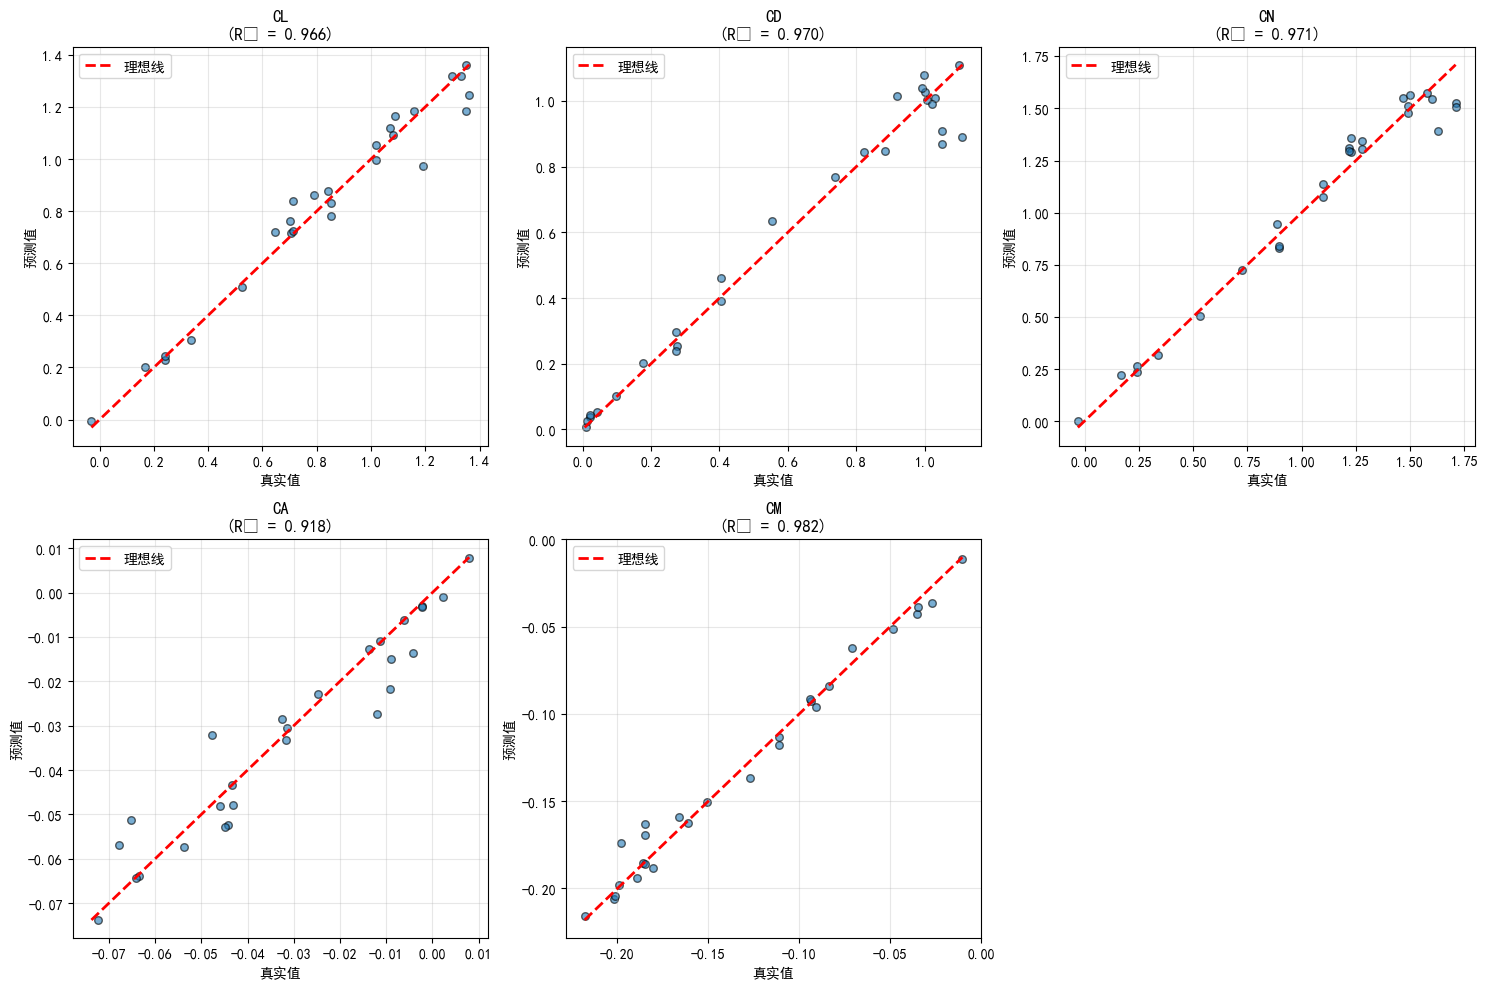

对比图已保存至 component_comparison_mlp.png

所有任务完成！MLP对比实验结束。


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

torch.manual_seed(42)

# ==================== 参数定义 ====================
epochs = 300

# ==================== 数据加载与预处理 ====================
print("开始加载数据...")
df = pd.read_excel('data_all.xlsx')
feature_columns = ['MA', 'BETA', 'AA']
target_columns = ['CL', 'CD', 'CN', 'CA', 'CM']
X = df[feature_columns].values
y = df[target_columns].values
print(X.shape, y.shape)

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)
print("数据标准化完成")

# 保存数据到Excel（略，保留原逻辑）
learn_data = pd.DataFrame(np.vstack([np.vstack([X_train, X_val]), X_test]), columns=feature_columns)
learn_targets = pd.DataFrame(np.vstack([np.vstack([y_train, y_val]), y_test]), columns=target_columns)
dataset_type = ['训练集'] * len(X_train) + ['验证集'] * len(X_val) + ['测试集'] * len(X_test)
learn_data['数据集类型'] = dataset_type
learn_combined = pd.concat([learn_data, learn_targets], axis=1)
with pd.ExcelWriter('学习数据集.xlsx') as writer:
    learn_combined.to_excel(writer, sheet_name='完整数据', index=False)
    learn_combined[learn_combined['数据集类型'] == '训练集'].to_excel(writer, sheet_name='训练集', index=False)
    learn_combined[learn_combined['数据集类型'] == '验证集'].to_excel(writer, sheet_name='验证集', index=False)
    learn_combined[learn_combined['数据集类型'] == '测试集'].to_excel(writer, sheet_name='测试集', index=False)
print("数据已保存至 '学习数据集.xlsx'")

# 转换为Tensor
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled)
X_val_tensor = torch.FloatTensor(X_val_scaled)
y_val_tensor = torch.FloatTensor(y_val_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test_scaled)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ==================== 简单MLP模型定义 ====================
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dims=[256, 128, 64], dropout=0.1):
        """
        多层感知机回归模型
        Args:
            input_dim: 输入特征维度
            output_dim: 输出维度
            hidden_dims: 隐藏层维度列表
            dropout: Dropout比率
        """
        super(SimpleMLP, self).__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, output_dim))
        self.network = nn.Sequential(*layers)
        
        # 可选：添加一个残差直连（从输入到输出，类似原FTTransformer的linear_shortcut）
        # 为了对比公平，也加入一个可学习的线性残差（初始化为0）
        self.shortcut = nn.Linear(input_dim, output_dim)
        nn.init.constant_(self.shortcut.weight, 0.0)
        nn.init.constant_(self.shortcut.bias, 0.0)
    
    def forward(self, x):
        # 残差连接：深度网络输出 + 线性变换输入
        return self.network(x) + self.shortcut(x)

# ==================== 损失函数与训练准备 ====================
def combined_loss(y_true, y_pred):
    mse = nn.MSELoss()(y_true, y_pred)
    mae = nn.L1Loss()(y_true, y_pred)
    return mse 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleMLP(input_dim=X_train.shape[1], output_dim=5,
                  hidden_dims=[256, 128, 64], dropout=0.1).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                                                       patience=15, min_lr=1e-8, verbose=True)

# ==================== 训练函数（与原代码完全一致） ====================
def train_model(model, train_loader, val_loader, optimizer, scheduler, epochs=epochs):
    train_losses = []
    val_losses = []
    train_rmses = []
    val_rmses = []
    train_maes = []
    val_maes = []
    learning_rates = []
    best_val_rmse = float('inf')
    patience = 3000
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_rmse = 0.0
        train_mae = 0.0
        train_mse = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            y_pred = model(batch_X)
            loss = combined_loss(batch_y, y_pred)
            mse = nn.MSELoss()(y_pred, batch_y)
            rmse = torch.sqrt(mse)
            mae = nn.L1Loss()(y_pred, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
            train_rmse += rmse.item()
            train_mae += mae.item()
            train_mse += mse.item()

        model.eval()
        val_loss = 0.0
        val_rmse = 0.0
        val_mae = 0.0
        val_mse = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = combined_loss(batch_y, outputs)
                mse = nn.MSELoss()(outputs, batch_y)
                rmse = torch.sqrt(mse)
                mae = nn.L1Loss()(outputs, batch_y)
                val_loss += loss.item()
                val_rmse += rmse.item()
                val_mae += mae.item()
                val_mse += mse.item()

        train_loss /= len(train_loader)
        train_rmse /= len(train_loader)
        train_mae /= len(train_loader)
        train_mse /= len(train_loader)
        val_loss /= len(val_loader)
        val_rmse /= len(val_loader)
        val_mae /= len(val_loader)
        val_mse /= len(val_loader)

        scheduler.step(val_rmse)
        current_lr = optimizer.param_groups[0]['lr']

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_rmses.append(train_rmse)
        val_rmses.append(val_rmse)
        train_maes.append(train_mae)
        val_maes.append(val_mae)
        learning_rates.append(current_lr)

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            torch.save(model.state_dict(), 'best_model_mlp.pth')
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print('早停触发')
            break

        if (epoch + 1) % 20 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
                  f'Train RMSE: {train_rmse:.4f}, Val RMSE: {val_rmse:.4f}, '
                  f'Train MAE: {train_mae:.4f}, Val MAE: {val_mae:.4f}, '
                  f'Train MSE: {train_mse:.4f}, Val MSE: {val_mse:.4f}, LR: {current_lr:.6f}')

    history = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_rmses': train_rmses,
        'val_rmses': val_rmses,
        'train_maes': train_maes,
        'val_maes': val_maes,
        'learning_rates': learning_rates,
    }
    model.load_state_dict(torch.load('best_model_mlp.pth'))
    return history

# ==================== 评估函数（与原代码完全一致） ====================
def evaluate_model(model, data_loader, scaler_y, device):
    """
    评估模型，返回总体指标和每个输出分量的指标（RMSE, MAE, R2, MRE）
    """
    model.eval()
    all_preds = []
    all_trues = []
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            outputs = model(batch_X)
            all_preds.append(outputs.cpu().numpy())
            all_trues.append(batch_y.cpu().numpy())
    all_preds = np.vstack(all_preds)
    all_trues = np.vstack(all_trues)

    # 逆标准化到原始尺度
    all_preds_orig = scaler_y.inverse_transform(all_preds)
    all_trues_orig = scaler_y.inverse_transform(all_trues)

    # 总体指标（原始尺度）
    total_mse = mean_squared_error(all_trues_orig, all_preds_orig)
    total_rmse = np.sqrt(total_mse)
    total_mae = mean_absolute_error(all_trues_orig, all_preds_orig)
    total_r2 = r2_score(all_trues_orig, all_preds_orig)
    # 自定义组合损失（在原始尺度上重新计算）
    mse_loss = np.mean((all_trues_orig - all_preds_orig) ** 2)
    mae_loss = np.mean(np.abs(all_trues_orig - all_preds_orig))
    total_combined = mse_loss + 0.33 * mae_loss

    # 每个分量的指标
    n_outputs = all_trues_orig.shape[1]
    component_metrics = {}
    for i in range(n_outputs):
        y_true_i = all_trues_orig[:, i]
        y_pred_i = all_preds_orig[:, i]
        rmse_i = np.sqrt(mean_squared_error(y_true_i, y_pred_i))
        mae_i = mean_absolute_error(y_true_i, y_pred_i)
        r2_i = r2_score(y_true_i, y_pred_i)
        epsilon = 1e-8
        mre_i = np.mean(np.abs((y_true_i - y_pred_i) / (np.abs(y_true_i) + epsilon)))
        component_metrics[i] = {'RMSE': rmse_i, 'MAE': mae_i, 'R2': r2_i, 'MRE': mre_i}

    overall_metrics = {
        'MSE': total_mse,
        'RMSE': total_rmse,
        'MAE': total_mae,
        'R2': total_r2,
        'Combined_Loss': total_combined
    }
    return overall_metrics, component_metrics, (all_trues_orig, all_preds_orig)

# ==================== 训练模型 ====================
print('开始训练MLP模型...')
history = train_model(model, train_loader, val_loader, optimizer, scheduler, epochs=epochs)
print('训练完成，加载最佳MLP模型')

# ==================== 评估并输出分量指标 ====================
print("\n===== 测试集评估结果（原始尺度） =====")
test_overall, test_component, (test_true, test_pred) = evaluate_model(model, test_loader, scaler_y, device)

print(f"总体指标: MSE={test_overall['MSE']:.4f}, RMSE={test_overall['RMSE']:.4f}, MAE={test_overall['MAE']:.4f}, R2={test_overall['R2']:.4f}, Combined={test_overall['Combined_Loss']:.4f}")

print("\n各分量详细指标:")
components_name = target_columns
for i, name in enumerate(components_name):
    m = test_component[i]
    print(f"{name}: RMSE={m['RMSE']:.4f}, MAE={m['MAE']:.4f}, R2={m['R2']:.4f}, MRE={m['MRE']:.4%}")

# 可选：同时输出训练集和验证集的指标（供参考）
print("\n===== 训练集评估结果（原始尺度） =====")
train_overall, train_component, _ = evaluate_model(model, train_loader, scaler_y, device)
print(f"总体RMSE={train_overall['RMSE']:.4f}, R2={train_overall['R2']:.4f}")

print("\n===== 验证集评估结果（原始尺度） =====")
val_overall, val_component, _ = evaluate_model(model, val_loader, scaler_y, device)
print(f"总体RMSE={val_overall['RMSE']:.4f}, R2={val_overall['R2']:.4f}")

# ==================== 可视化：五个分量的真实值与预测值对比 ====================
def plot_true_vs_pred(true, pred, target_names, save_path='component_comparison_mlp.png'):
    """
    绘制每个分量的真实值与预测值散点图（含对角线）
    """
    n = len(target_names)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for i, name in enumerate(target_names):
        ax = axes[i]
        ax.scatter(true[:, i], pred[:, i], alpha=0.6, edgecolors='k', s=30)
        # 对角线
        min_val = min(true[:, i].min(), pred[:, i].min())
        max_val = max(true[:, i].max(), pred[:, i].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='理想线')
        ax.set_xlabel('真实值')
        ax.set_ylabel('预测值')
        ax.set_title(f'{name}\n(R² = {test_component[i]["R2"]:.3f})')
        ax.legend()
        ax.grid(True, alpha=0.3)
    # 隐藏多余的子图（如果有）
    if n < len(axes):
        axes[-1].set_visible(False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"对比图已保存至 {save_path}")

plot_true_vs_pred(test_true, test_pred, target_columns)

print("\n所有任务完成！MLP对比实验结束。")